# 4. Predict observables and generate mocks

This notebook defines its own JAX model and physical parameters below.
It builds on the [model tutorial](models.ipynb#compose-the-jax-model). Always distinguish a
projected observable from an intrinsic quantity and a dispersion from a variance.


This notebook is self-contained. Install JeansPy with the `numpyro_cpu` and
`plotting` extras as described in the installation guide, then select that
environment as your Jupyter kernel and run cells from top to bottom.
Saved outputs are an example run; timings and short-chain results can vary.

## Setup

Run this setup in a fresh kernel. It defines all objects used below.

The generalized NFW halo uses `ZhaoModel` with fixed `alpha=1`, `beta=3`
and an untruncated cutoff. Its inner slope `gamma` is sampled in the
inference examples; `truth["gamma"]=1` generates standard-NFW mocks.

In [1]:
import os
os.environ.setdefault("JEANSPY_JAX_PLATFORM", "cpu")
os.environ.setdefault("JEANSPY_JAX_ENABLE_X64", "true")

# The example uses no progress widgets; ignore only their optional-import warning.
import warnings
warnings.filterwarnings("ignore", message="IProgress not found.*")

# Import JeansPy before JAX so its runtime settings take effect.
from jeanspy.model_jax import (
    DSphModel, PlummerModel, ZhaoModel, ConstantAnisotropyModel,
)
from jeanspy.sampler_numpyro import JeansLikelihoodModel, ParameterSpec
import jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
import numpy as np
import matplotlib.pyplot as plt

model = DSphModel(submodels={
    "StellarModel": PlummerModel(),
    "DMModel": ZhaoModel(),
    "AnisotropyModel": ConstantAnisotropyModel(),
})
fixed = dict(re_pc=200., alpha=1., beta=3., r_t_pc=np.inf)
truth = dict(**fixed, rs_pc=500., rhos_Msunpc3=.1, gamma=1., beta_ani=0.)
options = dict(solver="kernel", n_u=128, n_kernel=32,
               dm_mass_method="numeric", dm_mass_n_steps=128)

In [2]:
rng = np.random.default_rng(123)
u = rng.uniform(size=32)
R_pc = 200. * np.sqrt(u / (1. - u))  # Projected Plummer radii.
e_vlos_kms = np.full(32, 2.)
variance = np.asarray(model.sigmalos2(R_pc, params=truth, **options))
vlos_kms = rng.normal(0., np.sqrt(variance + e_vlos_kms**2))
data = dict(R_pc=R_pc, vlos_kms=vlos_kms, e_vlos_kms=e_vlos_kms)

In [3]:
import jax.numpy as jnp
params = dict(truth)

## Calculate the LOS dispersion

In [4]:
import jax.numpy as jnp

variance = model.sigmalos2(R_pc, params=params, solver="kernel",
                          n_u=256, n_kernel=64)
sigma_kms = jnp.sqrt(variance)

`sigmalos2` returns the intrinsic LOS second central moment in (km/s)².
The mean velocity does not belong inside its square root. NumPy users can
call `model.sigmalos(R_pc, n=256, n_kernel=64)` directly on a NumPy/SciPy model;
JAX users take the square root as above. The different keyword names are
documented in the individual
[NumPy](https://gomeshun.github.io/jeanspy/dev/api/all.html) and
[JAX](https://gomeshun.github.io/jeanspy/dev/api/all.html) API entries.

## Plot a radial profile

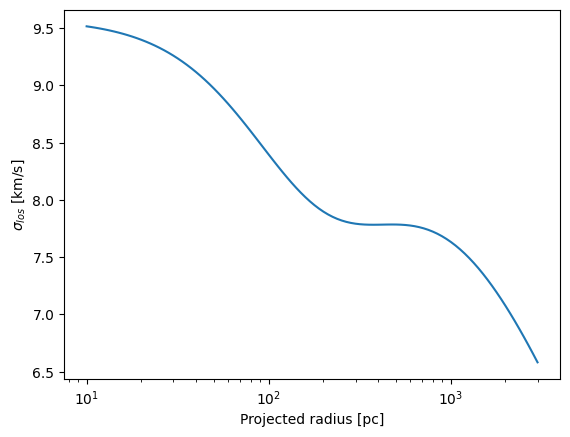

In [5]:
import numpy as np
import matplotlib.pyplot as plt

R_grid = np.geomspace(10., 3000., 100)
sigma_grid = np.sqrt(model.sigmalos2(
    R_grid, params=params, solver="kernel", n_u=256, n_kernel=64))
fig, ax = plt.subplots()
ax.semilogx(R_grid, sigma_grid)
ax.set(xlabel="Projected radius [pc]", ylabel=r"$\sigma_{los}$ [km/s]")
plt.show()

These host-side NumPy conversions are for plotting, after evaluation; keep
JAX operations inside a differentiated likelihood. To check numerical
stability, evaluate the same physical parameters and radii with larger
`n_u` and `n_kernel` and compare the predictions. A finer radius grid makes
the plot smoother but does not refine the underlying integration.

## Inspect the components

In [6]:
tracer = model["StellarModel"]
halo = model["DMModel"]
surface_density = tracer.density_2d(R_grid, re_pc=params["re_pc"])
r_grid = np.geomspace(10., 3000., 100)
spatial_density = tracer.density_3d(r_grid, re_pc=params["re_pc"])
halo_density = halo.mass_density_3d(r_grid, params=params)
mass = halo.enclosed_mass(r_grid, params=params)

The tracer densities are number-weighting functions; the halo density and
mass set the potential. Halo density and mass methods can apply different
cutoff conventions. Read the selected halo's API entry before using its
density in a custom integral. J/D factors additionally require a distance
and an angular aperture; follow the [factor guide](../guides/factors.md).

## Generate mock observations

At a fixed observed radius, the Gaussian likelihood assumes

$$
v_i \sim \mathcal{N}\!\left(v_{\rm mem},
\sigma_{\rm los}^2(R_i)+\epsilon_i^2\right).
$$

In this expression the second argument is the **variance**. NumPy's
`rng.normal` expects its square root as `scale`. The Quickstart implements
this explicitly:

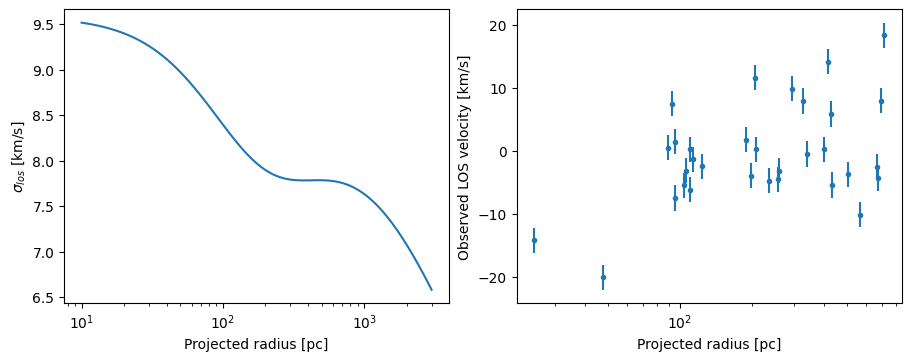

In [7]:
rng = np.random.default_rng(123)
u = rng.uniform(size=32)
R_pc = 200. * np.sqrt(u / (1. - u))  # Projected Plummer radii.
e_vlos_kms = np.full(32, 2.)
variance = np.asarray(model.sigmalos2(R_pc, params=truth, **options))
vlos_kms = rng.normal(0., np.sqrt(variance + e_vlos_kms**2))
data = dict(R_pc=R_pc, vlos_kms=vlos_kms, e_vlos_kms=e_vlos_kms)

R_grid = np.geomspace(10., 3000., 100)
sigma_kms = np.sqrt(model.sigmalos2(R_grid, params=truth, **options))
prediction, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
axes[0].semilogx(R_grid, sigma_kms)
axes[0].set(xlabel="Projected radius [pc]", ylabel=r"$\sigma_{los}$ [km/s]")
axes[1].errorbar(R_pc, vlos_kms, yerr=e_vlos_kms, fmt=".")
axes[1].set(xscale="log", xlabel="Projected radius [pc]",
            ylabel="Observed LOS velocity [km/s]")
plt.show()

The setup above supplies `fixed`, `truth` and `options` for this mock.
The inverse Plummer CDF gives projected radii; real surveys may need spatial
selection, membership and measurement-error models. Generating Gaussian
velocities tests the assumed likelihood workflow, not a self-consistent
phase-space distribution. For an observed dataset the velocity likelihood
conditions on the supplied radii, so it does not also fit their distribution.

Next: [turn predictions into an MCMC likelihood](inference.ipynb).